In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kavyakatal/housingbig-dataset/train (1).csv


In [6]:
# ============================================
# Step 1: Import Required Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("/kaggle/input/datasets/kavyakatal/housingbig-dataset/train (1).csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
df.shape

(1460, 81)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
df.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

In [11]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percentage
})

missing_df = missing_df[missing_df["Missing Values"] > 0] \
                .sort_values(by="Percentage (%)", ascending=False)

missing_df.head(20)

,Missing Values,Percentage (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


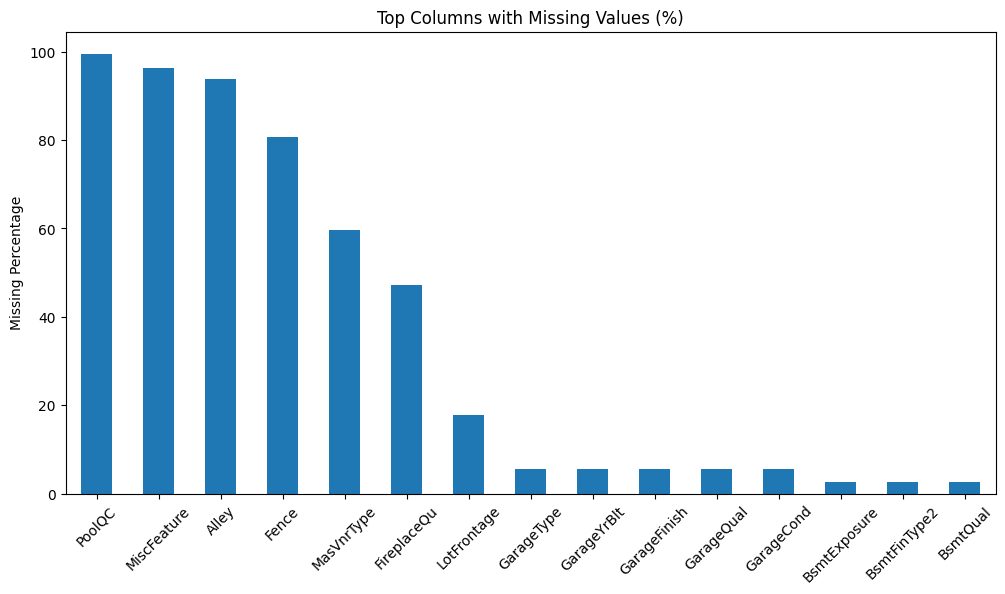

In [13]:
plt.figure(figsize=(12,6))

missing_df["Percentage (%)"].head(15).plot(kind="bar")

plt.title("Top Columns with Missing Values (%)")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=45)

plt.show()

In [14]:
drop_cols = ["PoolQC", "MiscFeature", "Alley", "Fence"]

df.drop(columns=drop_cols, inplace=True)

df.shape

(1460, 77)

In [15]:
# Separate numerical and categorical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns


# Fill numerical columns using Median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


# Fill categorical columns using Mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [18]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 77, dtype: int64

In [19]:
# ============================================
# Step 6: Separate Target Variable
# ============================================

y = df["SalePrice"]

X = df.drop("SalePrice", axis=1)

In [20]:
X.drop("Id", axis=1, inplace=True)

### Feature Selection

The `Id` column was removed since it represents a unique
identifier and does not contribute to property price prediction.

The target variable `SalePrice` was separated from the
feature dataset before encoding and model preparation.

In [21]:
categorical_cols = X.select_dtypes(include=["object"]).columns

len(categorical_cols)

39

In [24]:
X = pd.get_dummies(X, drop_first=True)
# One Hot Encoding

### Categorical Feature Encoding

Categorical variables were converted into numerical format
using One-Hot Encoding.

The `drop_first=True` parameter was used to prevent
multicollinearity issues commonly known as the
dummy variable trap in regression models.

This transformation enables machine learning models
to effectively interpret categorical property attributes.

In [25]:
X.shape

(1460, 235)

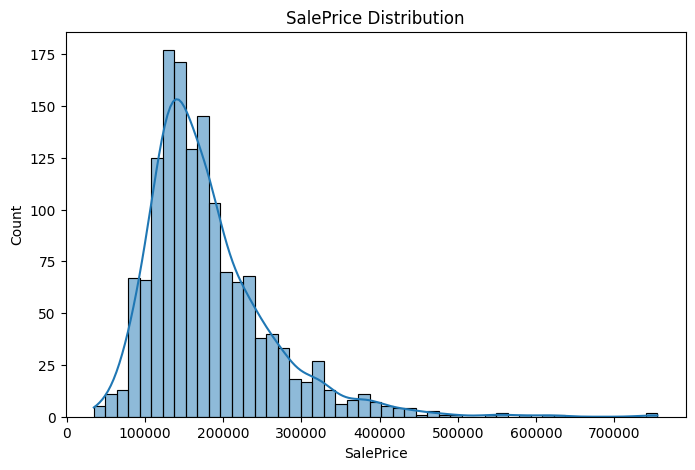

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(y, kde=True)
plt.title("SalePrice Distribution")
plt.show()
#Skewness Check

In [ ]:
# ============================================
# Step 7: Log Transform Target Variable
# ============================================

y = np.log1p(y)

### Target Variable Transformation

The SalePrice variable exhibited right-skewed distribution,
which can negatively impact regression model performance.

A logarithmic transformation was applied using log1p()
to normalize price distribution and improve model learning
stability.

In [27]:
# ============================================
# Step 8: Train Test Split
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
X_train.shape, X_test.shape

((1168, 235), (292, 235))

In [29]:
X_train.shape

(1168, 235)

In [30]:
# ============================================
# Step 9: Linear Regression Model Training
# ============================================

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [31]:
y_pred_lr = lr_model.predict(X_test)

In [32]:
# Linear Regression Evaluation

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Results
MAE: 20434.217394432228
RMSE: 52298.8715436497
R2 Score: 0.6434086516194962


### Linear Regression Model

Linear Regression was used as a baseline regression model
to understand relationships between housing features and
property prices.

Model performance was evaluated using:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [33]:
# ============================================
# Step 10: Random Forest Training
# ============================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [42]:
y_pred_rf = rf_model.predict(X_test)

mae_log = mean_absolute_error(y_test, y_pred_rf)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("FINAL RANDOM FOREST (LOG SCALE)")
print("MAE :", mae_log)
print("RMSE:", rmse_log)
print("R2  :", r2)

FINAL RANDOM FOREST (LOG SCALE)
MAE : 17473.082945205482
RMSE: 28502.162406883006
R2  : 0.8940888249176238


In [43]:
# ============================================
# Step 11: Model Performance Comparison
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ---------- Linear Regression ----------
y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)


# ---------- Random Forest ----------
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)


# ---------- Print Results ----------
print("========== MODEL COMPARISON ==========\n")

print("Linear Regression Results")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

print("\n-----------------------------------\n")

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

========== MODEL COMPARISON ==========

Linear Regression Results
MAE : 20434.217394432228
RMSE: 52298.8715436497
R2 Score: 0.6434086516194962

-----------------------------------

Random Forest Results
MAE : 17473.082945205482
RMSE: 28502.162406883006
R2 Score: 0.8940888249176238


In [45]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test_real.values[:10],
    "Predicted Price": y_pred_real[:10]
})

comparison_df

,Actual Price,Predicted Price
0,inf,inf
1,inf,inf
2,inf,inf
3,inf,inf
4,inf,inf
5,inf,inf
6,inf,inf
7,inf,inf
8,inf,inf
9,inf,inf


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_rf = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("FINAL RANDOM FOREST (REAL PRICE SCALE)")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

FINAL RANDOM FOREST (REAL PRICE SCALE)
MAE : 17473.082945205482
RMSE: 28502.162406883006
R2  : 0.8940888249176238


In [49]:
import joblib

artifacts = {
    "model": rf_model,
    "feature_columns": list(X.columns),
    "log_target": False
}

joblib.dump(artifacts, "ames_rf_model.joblib")
print("Saved: ames_rf_model.joblib")

Saved: ames_rf_model.joblib


In this training run, the target `SalePrice` was used in original scale (no log transform).  
Therefore predictions and evaluation metrics are reported in real price units.